# Visibility-Constrained Faction Control Problem

If you're here for the interactive demo: Just run every section in this part and *Input Generation*!

In [ ]:
# pip install shapely

## 1. Object Definitions

**Playing Region**: 2D plane of size $(Ω_x, Ω_y)$

**Agent**: A point in $Ω$ at position $(p_x,p_y)$

**Obstacle**: A simple polygon in $\Omega$

**Faction**: A set of Agents.

In [1]:
import shapely
import numpy
import math
import matplotlib.pyplot as plt

In [ ]:
class PlayingRegion:
    def __init__(self, x: float, y: float):
        # the playing region's coordinates are from (0,0) to (x,y)
        self.x: float = x
        self.y: float = y
        self.polygon: shapely.Polygon = shapely.Polygon([(0,0), (x,0), (x,y), (0,y)])

class Agent:
    def __init__(self, x: float, y: float):
        self.x: float = x
        self.y: float = y
        self.point: shapely.Point = shapely.Point(x, y)
        self.visibility_region: shapely.Polygon = None
        self.control_region: shapely.MultiPolygon = None

class Obstacle:
    def __init__(self, pointlist: list[tuple[float, float]]):
        self.pointlist: list[tuple[float, float]] = pointlist
        self.polygon: shapely.Polygon = shapely.Polygon(pointlist)

class Faction:
    def __init__(self, agentlist: list[Agent]):
        self.control_region: shapely.MultiPolygon = None
        self.agentlist: list[Agent] = []
        for agent in agentlist:
            self.add_agent(agent)

    def add_agent(self, agent: Agent):
        if agent not in self.agentlist:
            self.agentlist.append(agent)

grid_size = 1e-6

## Visibility

**Visibility**: A point r is visible to an agent p if pr does not intersect obstacles.

**Visible Region**: The visible region of an agent p is the set of all points visible to p.

In [ ]:
# helper: returns a line from a point to a far point outside the playing region
def raycast(p: shapely.Point, angle: float, r: PlayingRegion):
    radius = r.x + r.y
    far_point = shapely.Point(p.x + math.cos(angle) * radius, p.y + math.sin(angle) * radius)
    return shapely.LineString([(p.x, p.y), (far_point.x, far_point.y)])

# helper: extract edges as list of tuples from obstacles and playing region
def collect_edges(obstacles: list[Obstacle], region: PlayingRegion):
    edges = []

    # obstacles
    for obs in obstacles:
        coords = list(obs.polygon.exterior.coords)
        for i in range(len(coords) - 1):
            edges.append((coords[i], coords[i+1]))

    # playing region
    coords = list(region.polygon.exterior.coords)
    for i in range(len(coords) - 1):
        edges.append((coords[i], coords[i+1]))

    return edges

In [ ]:
# probably unused: an implementation of whether a point is visible
def visible(p: Agent, r: shapely.Point, obstacles: list[Obstacle]):
    seg = shapely.LineString([p.point, r])
    for obstacle in obstacles:
        if seg.crosses(obstacle.polygon) or seg.within(obstacle.polygon):
            return False
    return True

# returns a polygon representing the visible region of p
def visible_region(p: Agent, obstacles: list[Obstacle], region: PlayingRegion):
    px, py = p.x, p.y

    angles = []
    edges = collect_edges(obstacles, region)
    for (x1, y1), (x2, y2) in edges:
        for vx, vy in [(x1, y1), (x2, y2)]:
            theta = math.atan2(vy - py, vx - px)
            angles.extend([theta - 1e-9, theta, theta + 1e-9])

    intersections = []

    for theta in angles:
        # cast ray, find minimum hit point, append to intersections
        ray = raycast(p.point, theta, region)

        closest_point = None
        min_dist = float("inf")

        for (x1, y1), (x2, y2) in edges:
            segment = shapely.LineString([(x1, y1), (x2, y2)])
            inter = ray.intersection(segment)

            if not inter.is_empty:
                if isinstance(inter, shapely.Point):
                    dist = inter.distance(p.point)
                    if dist < min_dist:
                        min_dist = dist
                        closest_point = inter

        if closest_point:
            intersections.append((theta, closest_point))

    # sort by angle
    intersections.sort(key=lambda x: x[0])

    # extract polygon
    points = [pt for _, pt in intersections]

    p.visibility_region = shapely.set_precision(shapely.Polygon([(pt.x, pt.y) for pt in points]).simplify(1e-6, preserve_topology=True), grid_size)
    return p.visibility_region

### Checkpoint 1

**Checkpoint:** Verify the algorithm for obtaining the visible region.

In [ ]:
from matplotlib.path import Path
from matplotlib.patches import PathPatch

def polygon_to_path(poly):
    vertices = []
    codes = []

    # --- exterior ---
    x, y = poly.exterior.coords.xy
    exterior = list(zip(x, y))

    vertices.extend(exterior)
    codes.extend([Path.MOVETO] + [Path.LINETO]*(len(exterior)-2) + [Path.CLOSEPOLY])

    # --- holes ---
    for interior in poly.interiors:
        x, y = interior.coords.xy
        ring = list(zip(x, y))

        vertices.extend(ring)
        codes.extend([Path.MOVETO] + [Path.LINETO]*(len(ring)-2) + [Path.CLOSEPOLY])

    return Path(vertices, codes)

# helper to plot simulation scene at this step
def plot_scene(agent: Agent, obstacles: list[Obstacle], region: PlayingRegion=None):
    fig, ax = plt.subplots()

    visibility_polygon = agent.visibility_region

    # --- Plot playing region (optional) ---
    if region is not None:
        x, y = region.polygon.exterior.xy
        ax.fill(x, y, alpha=0.05, edgecolor='black', linewidth=1, label="Region")

    # --- Plot obstacles ---
    for i, obs in enumerate(obstacles):
        poly = obs.polygon
        x, y = poly.exterior.xy
        ax.fill(x, y, alpha=0.6, edgecolor='black', linewidth=1)

    # --- Plot visibility polygon ---
    if visibility_polygon is not None:
        if isinstance(visibility_polygon, shapely.Polygon):
            polys = [visibility_polygon]
        elif isinstance(visibility_polygon, shapely.MultiPolygon):
            polys = list(visibility_polygon.geoms)
        else:
            polys = []

        for poly in polys:
            path = polygon_to_path(poly)
            patch = PathPatch(path, edgecolor='blue', alpha=0.3, linewidth=1)
            ax.add_patch(patch)

    # --- Plot agent ---
    ax.plot(agent.x, agent.y, 'ro', label="Agent")

    # --- Formatting ---
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlim(0, region.x if region else None)
    ax.set_ylim(0, region.y if region else None)

    ax.set_title("Visibility Visualization")
    ax.legend(loc="upper right")

    plt.show()

POLYGON ((0 10, 10 10, 10 9.5, 7 8, 6 6, 8 6, 10 6.285714, 10 2, 4 4, 2 4, 2 2, 2.666667 0, 0 0, 0 10))


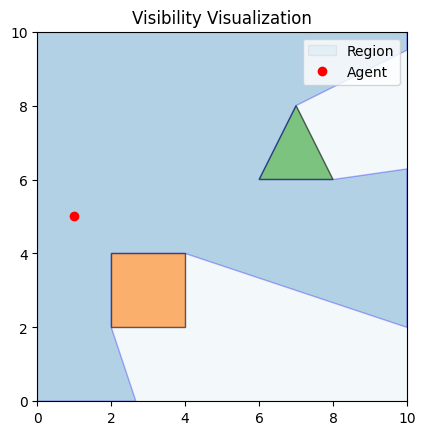

In [ ]:
region = PlayingRegion(10, 10)

agent = Agent(1, 5)

obstacles = [
    Obstacle([(2,2), (4,2), (4,4), (2,4)]),
    Obstacle([(6,6), (8,6), (7,8)])
]

# ill-behaved if obstacles clip into each other
vis_poly = visible_region(agent, obstacles, region)

print(agent.visibility_region)

plot_scene(agent, obstacles, region)

## Control

**Control**: A point r is in control of an agent p if it is visible to p and for every other agent q it is not visible to q or $dist(q,r) > dist(p,r)$
**Control Region**: An agent p controls a region R if all points in R is in control of p.

In [ ]:
from shapely.ops import split

# helper to make a half plane
def make_distance_half_plane(p: Agent, q: Agent, region: PlayingRegion) -> shapely.Polygon:
    """
    Returns a polygon approximating the half-plane where
    d(p, r) > d(q, r)
    """
    px, py = p.x, p.y
    qx, qy = q.x, q.y

    # difference
    dx = qx - px
    dy = qy - py

    # perpendicular
    dx_ = dy
    dy_ = -dx

    # midpoint
    mx = (px + qx) / 2
    my = (py + qy) / 2

    # large number
    R = max(region.x, region.y) * 10

    # points of the half-plane
    bisector = shapely.LineString([
        (mx + dx_ * R, my + dy_ * R),
        (mx - dx_ * R, my - dy_ * R)
    ])

    split_polys = shapely.ops.split(region.polygon, bisector)

    # choose the one that does NOT contain p
    for geo in split_polys.geoms:
        if not geo.contains(p.point):
            return geo

In [ ]:
# here for definition of control
def in_control(p: Agent, agentlist: list[Agent], r: shapely.Point, o: list[Obstacle]):
    if not visible(p, r, o):
        return False

    for q in agentlist:
        if q == p:
            continue
        if not visible(q, r, o):
            continue
        if (
            (r.x - p.x)**2 + (r.y - p.y)**2 # dist(p,r)
            <=
            (r.x - q.x)**2 + (r.y - q.y)**2 # dist(q,r)
            ):
            return False
    return True

def control_region(agent: Agent, agentlist: list[Agent], obstacles: list[Obstacle], region: PlayingRegion):
    # --- Step 1: ensure visibility ---
    if not agent.visibility_region:
        visible_region(agent, obstacles, region)

    control_poly = agent.visibility_region

    if control_poly.is_empty:
        agent.control_region = control_poly
        return control_poly

    fq_list = []

    for q in agentlist:
        if q == agent:
            continue

        # ensure visibility for q
        if not q.visibility_region:
            visible_region(q, obstacles, region)

        vis_q = q.visibility_region

        # --- Step 2: build half-plane polygon D_Q ---
        D_q = make_distance_half_plane(agent, q, region)

        # --- Step 3: F_Q = Vis(Q) ∩ D_Q ---
        F_q = vis_q.intersection(D_q)

        if not F_q.is_empty:
            fq_list.append(F_q)

    # --- Step 4: union + single subtraction ---
    if fq_list:
        F_union = shapely.unary_union(fq_list)
        control_poly = control_poly.difference(F_union)

        # clean geometry once
        control_poly = control_poly.buffer(0)

    agent.control_region = shapely.set_precision(control_poly, grid_size)
    return agent.control_region

### Checkpoint 2
**Checkpoint:** Verify the algorithm for obtaining the control region.

In [ ]:
def plot_control_state(agentlist: list[Agent], obstacles: list[Obstacle], region: PlayingRegion):
    fig, ax = plt.subplots()

    if region is not None:
        x, y = region.polygon.exterior.xy
        ax.fill(x, y, alpha=0.05, edgecolor='black', linewidth=1)

    # --- Plot obstacles ---
    for obs in obstacles:
        x, y = obs.polygon.exterior.xy
        ax.fill(x, y, alpha=0.6, facecolor='black', edgecolor='black', linewidth=1)

    # --- Generate distinct colors per agent ---
    cmap = plt.get_cmap('tab10', len(agentlist))  # or 'tab20' if many agents

    # --- Plot control regions ---
    for i, agent in enumerate(agentlist):
        color = cmap(i)  # one fixed color per agent

        control_region = agent.control_region
        if control_region is not None:
            if isinstance(control_region, shapely.Polygon):
                polys = [control_region]
            elif isinstance(control_region, shapely.MultiPolygon):
                polys = list(control_region.geoms)
            else:
                polys = []

            for poly in polys:
                path = polygon_to_path(poly)
                patch = PathPatch(path, facecolor=color, edgecolor=color, alpha=0.3, linewidth=1)
                ax.add_patch(patch)

        # --- Plot agent ---
        ax.plot(agent.x, agent.y, 'o', color=color)

    # --- Formatting ---
    ax.set_aspect('equal', adjustable='box')
    if region:
        ax.set_xlim(0, region.x)
        ax.set_ylim(0, region.y)

    ax.set_title("Control Visualization")
    plt.show()

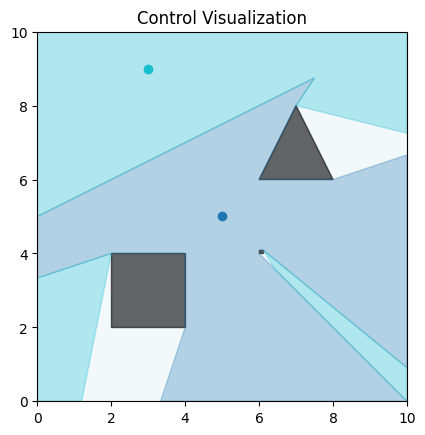

In [ ]:
region = PlayingRegion(10, 10)

agent1 = Agent(5,5)
agent2 = Agent(3,9)
agentlist = [agent1, agent2]

obstacles = [
    Obstacle([(2,2), (4,2), (4,4), (2,4)]),
    Obstacle([(6,6), (8,6), (7,8)]),
    Obstacle([(6,4),(6.1,4),(6.1,4.1),(6,4.1)])
]

for agent in agentlist:
    visible_region(agent, obstacles, region)

for agent in agentlist:
    control_region(agent, agentlist, obstacles, region)

plot_control_state(agentlist, obstacles, region)

## Faction

A faction F controls the region R if for all points r in R there exists some agent p in F such that r is under control of p.

In [ ]:
# faction stuff
def get_faction_control_region(faction: Faction):
    faction.control_region = shapely.unary_union([shapely.set_precision(a.control_region.buffer(0), grid_size) for a in faction.agentlist])
    return faction.control_region

In [ ]:
def plot_faction_control_state(factions: list[Faction], obstacles: list[Obstacle], region: PlayingRegion):
    fig, ax = plt.subplots()

    if region is not None:
        x, y = region.polygon.exterior.xy
        ax.fill(x, y, alpha=0.05, edgecolor='black', linewidth=1)

    # --- Plot obstacles ---
    for obs in obstacles:
        x, y = obs.polygon.exterior.xy
        ax.fill(x, y, alpha=0.6, facecolor='black', edgecolor='black', linewidth=1)

    # --- Generate distinct colors per faction ---
    cmap = plt.get_cmap('tab10', len(factions))  # or 'tab20' if many agents

    # --- Plot control regions ---
    for i, faction in enumerate(factions):
        color = cmap(i)  # one fixed color per faction

        control_region = faction.control_region
        if control_region is not None:
            if isinstance(control_region, shapely.Polygon):
                polys = [control_region]
            elif isinstance(control_region, shapely.MultiPolygon):
                polys = list(control_region.geoms)
            else:
                polys = []

            for poly in polys:
                path = polygon_to_path(poly)
                patch = PathPatch(path, facecolor=color, edgecolor=color, alpha=0.3, linewidth=1)
                ax.add_patch(patch)

        # --- Plot agent ---
        for agent in faction.agentlist:
            ax.plot(agent.x, agent.y, 'o', color=color)

    # --- Formatting ---
    ax.set_aspect('equal', adjustable='box')
    if region:
        ax.set_xlim(0, region.x)
        ax.set_ylim(0, region.y)

    ax.set_title("Control Visualization")
    plt.show()

In [ ]:
def baseline_algorithm(region: PlayingRegion, obs: list[Obstacle], agentlist: list[Agent], factions: list[Faction]):
    """
    Baseline algorithm for visibility-constrained faction control.
    Calculates each faction's control over the playing region and appends them to the object data.
    Returns the whole list of agents and factions, because that's easier to plot with.
    """

    for agent in agentlist:
        visible_region(agent, obs, region)

    for agent in agentlist:
        control_region(agent, agentlist, obs, region)

    for faction in factions:
        faction.control_region = get_faction_control_region(faction)

    return agentlist, factions

### Checkpoint 3
Verify that factions correctly display control regions

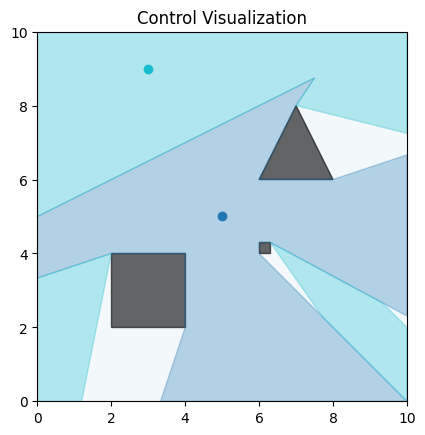

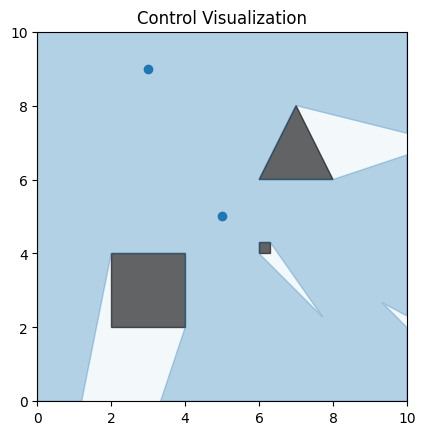

In [ ]:
region = PlayingRegion(10, 10)

agent1 = Agent(5,5)
agent2 = Agent(3,9)
agentlist = [agent1, agent2]

faction1 = Faction([agent1, agent2])
factions = [faction1]

obstacles = [
    Obstacle([(2,2), (4,2), (4,4), (2,4)]),
    Obstacle([(6,6), (8,6), (7,8)]),
    Obstacle([(6,4),(6.3,4),(6.3,4.3),(6,4.3)])
]

agentlist, factions = baseline_algorithm(region, obstacles, agentlist, factions)

plot_control_state(agentlist, obstacles, region)
plot_faction_control_state(factions, obstacles, region)

Next we make improvements according to the proposed approach.

## Optimization 1

Optimization 1: Use Asano's algorithm for visibility polygon calculation

In [ ]:
def angle(p: Agent, v: tuple[float, float]):
    px, py = p.x, p.y
    vx, vy = v[0], v[1]
    return math.atan2(vy - py, vx - px)

def dist2(p: Agent, v: tuple[float, float]):
    return (v[0] - p.x)**2 + (v[1] - p.y)**2

def collect_edges_and_vertices(poly: shapely.Polygon):
    coords = poly.exterior.coords
    vertices = [coords[i] for i in range(len(coords) - 1)]
    edges = [(coords[i], coords[i+1]) for i in range(len(coords) - 1)]

    return edges, vertices

def collect_all_edges_and_vertices(obstacles: list[Obstacle], region: PlayingRegion):

    polys = [region.polygon] + [obs.polygon for obs in obstacles]
    edges = []
    vertices = []
    for poly in polys:
        e, v = collect_edges_and_vertices(poly)
        edges.extend(e)
        vertices.extend(v)

    return edges, vertices

class Event:
    def __init__(self, point: tuple[float, float], angle: float, dist2: float):
        self.point = point
        self.angle = angle
        self.dist2 = dist2
        self.start_edges = []
        self.end_edges = []

    def as_str(self):
        return f"Point: {self.point}, Angle: {self.angle}, Dist2: {self.dist2}"

def normalize_angle(theta: float) -> float:
    if theta < 0:
        theta += 2 * math.pi
    return theta

def build_events(p: Agent, edges: list[tuple[tuple[float, float], tuple[float, float]]]):
    vertex_map: dict[tuple[float, float], Event] = {}

    def get_event(v):
        if v not in vertex_map:
            theta = normalize_angle(angle(p, v))
            vertex_map[v] = Event(v, theta, dist2(p, v))
        return vertex_map[v]

    for a, b in edges:
        ev_a = get_event(a)
        ev_b = get_event(b)

        theta_a = ev_a.angle
        theta_b = ev_b.angle

        # Compute angular difference
        d = theta_b - theta_a
        if d <= -math.pi:
            d += 2 * math.pi
        elif d > math.pi:
            d -= 2 * math.pi

        # If d > 0: a -> b is CCW small arc
        if d > 0:
            ev_a.start_edges.append((a, b))
            ev_b.end_edges.append((a, b))
        else:
            ev_b.start_edges.append((a, b))
            ev_a.end_edges.append((a, b))

    # Return events sorted by angle, then distance
    events = list(vertex_map.values())
    events.sort(key=lambda e: (e.angle, e.dist2))

    return events

def group_events(events: list[Event], eps=1e-9):
    groups = []
    events.sort(key=lambda e: e.angle)

    current = [events[0]]
    for e in events[1:]:
        if abs(e.angle - current[0].angle) < eps:
            current.append(e)
        else:
            groups.append(current)
            current = [e]
    groups.append(current)

    return groups

def visible_region_improved(p: Agent, obstacles: list[Obstacle], region: PlayingRegion):

    edges, _ = collect_all_edges_and_vertices(obstacles, region)
    events = build_events(p, edges)
    grouped_events = group_events(events)

    active_edges: list[tuple[tuple[float, float], tuple[float, float]]] = []

    def ray_dir(theta: float) -> tuple[float, float]:
        return math.cos(theta), math.sin(theta)

    def cross(ax, ay, bx, by):
        return ax * by - ay * bx

    def intersect(edge, theta):
        px, py = p.x, p.y
        rx, ry = math.cos(theta), math.sin(theta)

        (ax, ay), (bx, by) = edge
        sx, sy = bx - ax, by - ay

        rxs = cross(rx, ry, sx, sy)
        if abs(rxs) < 1e-9:
            return None  # parallel or collinear

        apx, apy = ax - px, ay - py

        t = cross(apx, apy, sx, sy) / rxs
        u = cross(apx, apy, rx, ry) / rxs

        if t < 0:
            return None  # behind ray

        if u < -1e-9 or u > 1 + 1e-9:
            return None  # outside segment

        ix = px + t * rx
        iy = py + t * ry

        return (ix, iy)

    def nearest_intersection(theta: float):
        closest = None
        best_dist = float('inf')

        for e in active_edges:
            pt = intersect(e, theta)
            if pt is not None:
                d = dist2(p, pt)
                if d < best_dist:
                    best_dist = d
                    closest = pt

        return closest

    # --- initialize active edges at angle 0 ---
    for e in edges:
        if intersect(e, 0.0) is not None:
            active_edges.append(e)

    points = []

    for group in grouped_events:
        theta = group[0].angle

        prev_pt = nearest_intersection(theta - 1e-9)

        # --- remove all ending edges first ---
        for ev in group:
            for e in ev.end_edges:
                if e in active_edges:
                    active_edges.remove(e)

        # --- then add all starting edges ---
        for ev in group:
            for e in ev.start_edges:
                active_edges.append(e)

        next_pt = nearest_intersection(theta + 1e-9)

        if prev_pt:
            points.append(prev_pt)
        if next_pt:
            points.append(next_pt)

    poly = shapely.Polygon(points)

    p.visibility_region = shapely.set_precision(poly.simplify(grid_size, preserve_topology=True), grid_size)
    return p.visibility_region

POLYGON ((10 2, 4 4, 2 4, 2 2, 2.666667 0, 0 0, 0 10, 10 10, 10 9.5, 7 8, 6 6, 8 6, 10 6.285714, 10 2))


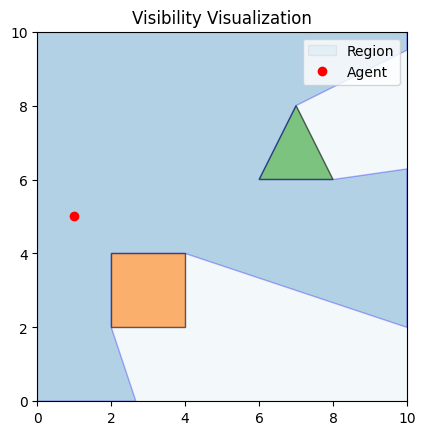

In [ ]:
region = PlayingRegion(10, 10)

agent = Agent(1, 5)

obstacles = [
    Obstacle([(2,2), (4,2), (4,4), (2,4)]),
    Obstacle([(6,6), (8,6), (7,8)])
]

visible_region_improved(agent, obstacles, region)

print(agent.visibility_region)

plot_scene(agent, obstacles, region)

## Optimization 2

Use `shapely.STRtree` to query only intersecting regions + early culling

In [ ]:
def bbox_intersects(bbox1: tuple[float, float, float, float], bbox2: tuple[float, float, float, float]) -> bool:
    # (minx1, miny1, maxx1, maxy1), (minx2, miny2, maxx2, maxy2)
    return not (bbox1[2] < bbox2[0] or bbox1[0] > bbox2[2] or
                bbox1[3] < bbox2[1] or bbox1[1] > bbox2[3])

def calculate_all_control_regions(agentlist: list[Agent], obstacles: list[Obstacle], region: PlayingRegion):
    for agent in agentlist:
        if not agent.visibility_region:
            visible_region_improved(agent, obstacles, region)

    tree = shapely.STRtree([q.visibility_region for q in agentlist])

    for agent in agentlist:
        control_poly = agent.visibility_region

        if control_poly.is_empty:
            agent.control_region = control_poly
            continue

        indices = tree.query(control_poly)

        for idx in indices:
            q = agentlist[idx]  # map back to agent

            if q is agent:
                continue

            vis_q = q.visibility_region

            if vis_q.is_empty:
                continue

            # bbox reject
            if not bbox_intersects(control_poly.bounds, vis_q.bounds):
                continue

            # build D_q late
            D_q = make_distance_half_plane(agent, q, region)

            if not bbox_intersects(control_poly.bounds, D_q.bounds):
                continue

            # now real intersection
            clip = vis_q.intersection(D_q)

            if clip.is_empty:
                continue

            control_poly = control_poly.difference(clip)

            if control_poly.is_empty:
                break

        agent.control_region = shapely.set_precision(control_poly, grid_size)

In [ ]:
def proposed_algorithm(region: PlayingRegion, obs: list[Obstacle], agentlist: list[Agent], factions: list[Faction]):
    """
    Proposed algorithm for visibility-constrained faction control.
    Calculates each faction's control over the playing region and appends them to the object data.
    Returns the whole list of agents and factions, because that's easier to plot with.
    """

    for agent in agentlist:
        visible_region_improved(agent, obs, region)

    calculate_all_control_regions(agentlist, obs, region)

    for faction in factions:
        faction.control_region = get_faction_control_region(faction)

    return agentlist, factions

### Checkpoint 4

Checkpoint: Verify correctness and equality between two algorithms

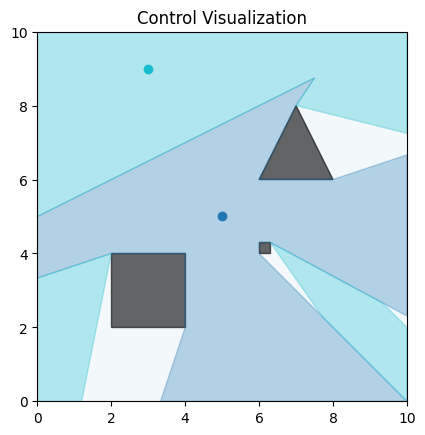

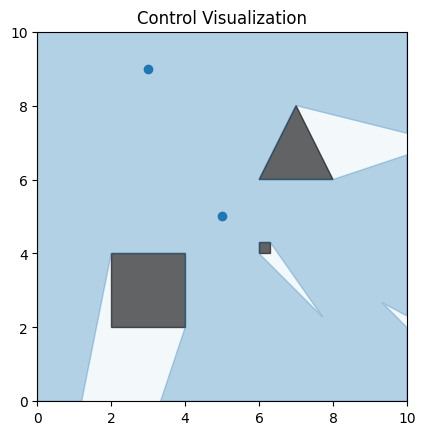

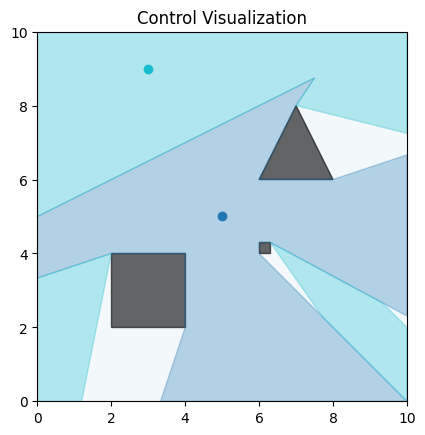

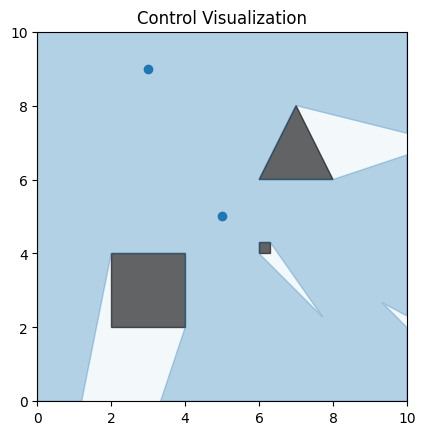

In [ ]:
region = PlayingRegion(10, 10)

agent1 = Agent(5,5)
agent2 = Agent(3,9)
agentlist = [agent1, agent2]

faction1 = Faction([agent1, agent2])
factions = [faction1]

obstacles = [
    Obstacle([(2,2), (4,2), (4,4), (2,4)]),
    Obstacle([(6,6), (8,6), (7,8)]),
    Obstacle([(6,4),(6.3,4),(6.3,4.3),(6,4.3)])
]

agentlist, factions = baseline_algorithm(region, obstacles, agentlist, factions)

plot_control_state(agentlist, obstacles, region)
plot_faction_control_state(factions, obstacles, region)

agentlist, factions = proposed_algorithm(region, obstacles, agentlist, factions)

plot_control_state(agentlist, obstacles, region)
plot_faction_control_state(factions, obstacles, region)

# Input Generation

Making inputs to test performance of both algorithms (painful)

In [ ]:
import random
import time
import numpy as np
from scipy.spatial import Voronoi

# --- Helper: Convert infinite Voronoi regions to finite polygons ---
def voronoi_finite_polygons_2d(vor, radius=None):
    """
    Reconstruct infinite Voronoi regions to finite regions.
    Source adapted from: https://stackoverflow.com/a/20678647
    """
    if vor.points.shape[1] != 2:
        raise ValueError("Requires 2D input")

    new_regions = []
    new_vertices = vor.vertices.tolist()

    center = vor.points.mean(axis=0)
    if radius is None:
        radius = np.ptp(vor.points).max() * 2

    # Map ridge vertices
    all_ridges = {}
    for (p1, p2), (v1, v2) in zip(vor.ridge_points, vor.ridge_vertices):
        all_ridges.setdefault(p1, []).append((p2, v1, v2))
        all_ridges.setdefault(p2, []).append((p1, v1, v2))

    for p1, region_idx in enumerate(vor.point_region):
        vertices = vor.regions[region_idx]

        if all(v >= 0 for v in vertices):
            new_regions.append(vertices)
            continue

        ridges = all_ridges[p1]
        new_region = [v for v in vertices if v >= 0]

        for p2, v1, v2 in ridges:
            if v2 < 0:
                v1, v2 = v2, v1
            if v1 >= 0:
                continue

            # Compute missing endpoint
            t = vor.points[p2] - vor.points[p1]
            t /= np.linalg.norm(t)
            n = np.array([-t[1], t[0]])

            midpoint = vor.points[[p1, p2]].mean(axis=0)
            direction = np.sign(np.dot(midpoint - center, n)) * n
            far_point = vor.vertices[v2] + direction * radius

            new_vertices.append(far_point.tolist())
            new_region.append(len(new_vertices) - 1)

        # Sort region vertices counterclockwise
        vs = np.asarray([new_vertices[v] for v in new_region])
        c = vs.mean(axis=0)
        angles = np.arctan2(vs[:, 1] - c[1], vs[:, 0] - c[0])
        new_region = [v for _, v in sorted(zip(angles, new_region))]

        new_regions.append(new_region)

    return new_regions, np.asarray(new_vertices)


# --- Helper: radial polygon inside a cell ---
def random_polygon_in_cell(cell: shapely.Polygon, v_min, v_max, shrink=0.8):
    """
    Generate a simple polygon inside a given shapely Polygon (cell)
    using radial sampling from centroid.
    """
    if cell.is_empty or not cell.is_valid:
        return None

    centroid = cell.centroid
    cx, cy = centroid.x, centroid.y

    n = random.randint(v_min, v_max)

    angles = np.sort(np.random.uniform(0, 2 * np.pi, n))
    points = []

    for theta in angles:
        dx, dy = np.cos(theta), np.sin(theta)

        # Ray from centroid
        far_point = shapely.Point(cx + dx * 1e5, cy + dy * 1e5)
        ray = shapely.Polygon([(cx, cy), (far_point.x, far_point.y), (far_point.x + 1e-6, far_point.y + 1e-6)])

        # Intersect ray with boundary
        line = cell.boundary.intersection(shapely.Point(cx, cy).buffer(1e5).boundary)

        # More robust: use a long segment
        from shapely.geometry import LineString
        ray_line = LineString([(cx, cy), (cx + dx * 1e5, cy + dy * 1e5)])
        inter = cell.boundary.intersection(ray_line)

        if inter.is_empty:
            continue

        # Extract farthest intersection point
        if "Point" in inter.geom_type:
            pts = [inter]
        else:
            pts = list(inter.geoms)

        dists = [(p.distance(centroid), p) for p in pts]
        _, boundary_pt = max(dists, key=lambda x: x[0])

        # Shrink inward
        px = cx + (boundary_pt.x - cx) * shrink
        py = cy + (boundary_pt.y - cy) * shrink
        points.append((px, py))

    if len(points) < 3:
        return None

    poly = shapely.Polygon(points)
    if not poly.is_valid:
        poly = poly.buffer(0)

    return poly if poly.is_valid else None


# --- Main function ---
def generate_large_M(
    M, x_max, y_max, v_min, v_max, seed=None
):
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)

    # Step 1: sample points
    points = np.column_stack((
        np.random.uniform(0, x_max, M),
        np.random.uniform(0, y_max, M)
    ))

    # Step 2: Voronoi
    vor = Voronoi(points)

    # Step 3: finite regions
    regions, vertices = voronoi_finite_polygons_2d(vor)

    bbox = shapely.box(0, 0, x_max, y_max)

    result = []

    for region in regions:
        poly_coords = vertices[region]
        cell = shapely.Polygon(poly_coords)

        # Step 4: clip to bounding box
        cell = cell.intersection(bbox)

        if cell.is_empty or not cell.is_valid:
            continue

        # Step 5: generate polygon inside cell
        poly = random_polygon_in_cell(cell, v_min, v_max)

        if poly is not None and bbox.contains(poly):
            result.append(poly)

    return result

def random_simple_polygon(n):
    angles = np.sort(np.random.uniform(0, 2*np.pi, n))
    radii = np.random.uniform(0.5, 1.0, n)

    points = [(r*np.cos(a), r*np.sin(a)) for r, a in zip(radii, angles)]
    return shapely.Polygon(points).buffer(0)


def generate_small_M(M, x_max, y_max, v_min, v_max, seed=None, max_attempts=1000):
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)

    polys = []

    attempts = 0
    while len(polys) < M and attempts < max_attempts:
        attempts += 1

        n = random.randint(v_min, v_max)
        poly = random_simple_polygon(n)

        # scale to reasonable size
        sx = random.uniform(5, x_max / 2)
        sy = random.uniform(5, y_max / 2)
        poly = shapely.affinity.scale(poly, sx, sy)

        # translate into box
        tx = random.uniform(0, x_max)
        ty = random.uniform(0, y_max)
        poly = shapely.affinity.translate(poly, tx, ty)

        # clip to bounds (optional but safer)
        bbox = shapely.Polygon([(0,0),(x_max,0),(x_max,y_max),(0,y_max)])
        poly = poly.intersection(bbox)

        if poly.is_empty or not poly.is_valid:
            continue

        if type(poly) == shapely.geometry.multipolygon.MultiPolygon:
            poly = poly.geoms[0]

        if all(not poly.intersects(p) for p in polys):
            polys.append(poly)

    return polys

def generate_polygons(M, x_max, y_max, v_min, v_max, seed=None):
    if M < 4:
        return generate_small_M(M, x_max, y_max, v_min, v_max, seed=seed)
    else:
        return generate_large_M(
            M, x_max, y_max, v_min, v_max, seed=seed
        )

def generate_obstacles(M, region, vertex_min, vertex_max, seed=None):
    obstacles = []
    polys = generate_polygons(M, region.x, region.y, vertex_min, vertex_max, seed=seed)
    for poly in polys:
        coords = [coord for coord in poly.exterior.coords]
        obstacles.append(Obstacle(coords))
    return obstacles

In [ ]:
def sample_agents_in_region(region: PlayingRegion, obstacles: list[Obstacle], agent_count: int, seed=None):
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)

    agentlist = []

    # make region but with holes
    region_poly = region.polygon
    obstacle_polys = [o.polygon for o in obstacles]
    region_with_holes = region_poly.difference(shapely.ops.unary_union(obstacle_polys))

    for _ in range(agent_count):
        while True:
            p = shapely.Point(random.uniform(0, region.x), random.uniform(0, region.y))

            # Check if it is inside the actual polygon
            if region_with_holes.contains(p):
                # ensure that the agent is not too close to other agents
                valid = True
                for a in agentlist:
                    if a.point.distance(p) < 0.001:
                        valid = False
                        break
                if valid:
                    agentlist.append(Agent(p.x, p.y))
                    break

    return agentlist

In [ ]:
def distribute_shuffled(N, B, seed=None):
    if N == 1:
        return [list(range(N))]

    if N < B or N < 2 or B < 2:
        raise ValueError("Require N >= B >= 2")

    rng = random.Random(seed)  # optional reproducibility
    data = list(range(N))
    rng.shuffle(data)

    q, r = divmod(N, B)
    result = []
    start = 0

    for i in range(B):
        size = q + 1 if i < r else q
        result.append(data[start:start + size])
        start += size

    return result

def assign_factions(agentlist: list[Agent], faction_count: int, seed=None):
    buckets = distribute_shuffled(len(agentlist), faction_count, seed=seed)
    factions = []
    for bucket in buckets:
        factions.append(Faction([agentlist[i] for i in bucket]))
    return factions

In [ ]:

class TestInput:
    def __init__(self, region: PlayingRegion, agentlist: list[Agent], obstacles: list[Obstacle], factions: list[Faction]):
        self.agentlist = agentlist
        self.obstacles = obstacles
        self.region = region
        self.factions = factions

    def run_test(self):

        start = time.perf_counter()
        agentlist, factions = proposed_algorithm(self.region, self.obstacles, self.agentlist, self.factions)
        end = time.perf_counter()
        proposed = end - start


        # reset agents and factions' computed regions
        for agent in self.agentlist:
            agent.visibility_region = None
            agent.control_region = None

        for faction in self.factions:
            faction.control_region = None

        start = time.perf_counter()
        agentlist, factions = baseline_algorithm(self.region, self.obstacles, self.agentlist, self.factions)
        end = time.perf_counter()
        baseline = end - start

        return baseline, proposed

def build_random_input(region_x: float = 10,
                       region_y: float = 10,
                       obstacle_count: int = 4,
                       obstacle_vertex_min: int = 3,
                       obstacle_vertex_max: int = 4,
                       faction_count: int = 2,
                       agent_count: int = 2) -> TestInput:
    if region_x < 1:
        region_x = 1
    if region_x > 1000000:
        region_x = 1000000
    if region_y < 1:
        region_y = 1
    if region_y > 1000000:
        region_y = 1000000
    if obstacle_count < 0:
        obstacle_count = 0
    if obstacle_count > 5000:
        obstacle_count = 5000
    if obstacle_vertex_min < 3:
        obstacle_vertex_min = 3
    if obstacle_vertex_max > 100:
        obstacle_vertex_max = 100
    if faction_count < 1:
        faction_count = 1
    if faction_count > 16:
        faction_count = 16
    if agent_count < faction_count:
        agent_count = faction_count
    if agent_count > 1000:
        agent_count = 1000

    region = PlayingRegion(region_x, region_y)

    obstacles = generate_obstacles(
        obstacle_count, region, obstacle_vertex_min,
        obstacle_vertex_max)

    agentlist = sample_agents_in_region(region, obstacles, agent_count)

    factions = assign_factions(agentlist, faction_count)

    return TestInput(region, agentlist, obstacles, factions)

POLYGON ((0 0, 10 0, 10 10, 0 10, 0 0))
[<POINT (7.867 9.212)>, <POINT (3.188 1.849)>]
[<POLYGON ((0.409 6.542, 0.409 4.036, 3.757 3.825, 0.409 6.542))>, <POLYGON ((9.498 6.195, 9.498 6.197, 7.242 3.557, 9.498 5.232, 9.498 6.195))>, <POLYGON ((7.456 2.72, 5.681 2.918, 5.386 2.951, 3.002 0.29, 7.456 2.72))>, <POLYGON ((4.378 9.277, 5.184 7.456, 7.834 8.009, 4.378 9.277))>]
[[<__main__.Agent object at 0x7f6e39c03830>], [<__main__.Agent object at 0x7f6e39c03590>]]


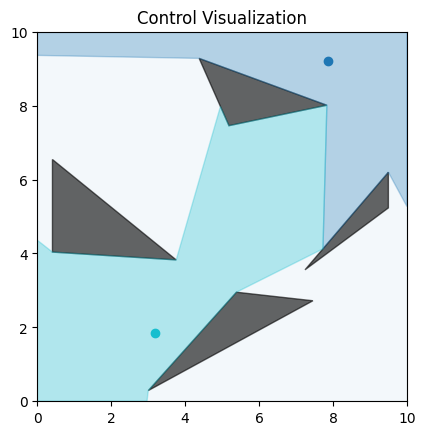

In [ ]:
test = build_random_input()
print(test.region.polygon)
print([a.point for a in test.agentlist])
print([o.polygon for o in test.obstacles])
print([f.agentlist for f in test.factions])

agentlist, factions = baseline_algorithm(test.region, test.obstacles, test.agentlist, test.factions)

plot_faction_control_state(factions, test.obstacles, test.region)

# Test Benches
Time to check execution!!!
(You don't have to run this part)

In [ ]:
class TestBench:
    def __init__(self, region_x: float,
                       region_y: float,
                       obstacle_count: int,
                       obstacle_vertex_min: int,
                       obstacle_vertex_max: int,
                       faction_count: int,
                       agent_count: int):
        self.region_x = region_x
        self.region_y = region_y
        self.obstacle_count = obstacle_count
        self.obstacle_vertex_min = obstacle_vertex_min
        self.obstacle_vertex_max = obstacle_vertex_max
        self.faction_count = faction_count
        self.agent_count = agent_count

    def bench(self, repetitions: int = 20):
        times = []
        for i in range(repetitions):
            testinput = build_random_input(self.region_x, self.region_y,
                                           self.obstacle_count,
                                           self.obstacle_vertex_min,
                                           self.obstacle_vertex_max,
                                           self.faction_count, self.agent_count)
            time = testinput.run_test()
            print(f"{i}/{repetitions}: {time[0]:.6f}, {time[1]:.6f}")
            times.append(time)

        baseline = [t[0] for t in times]
        proposed = [t[1] for t in times]

        print("=== Results ===")
        print(f"Baseline Average: {np.mean(baseline):.6f} seconds")
        print(f"Baseline Standard Deviation: {np.std(baseline):.6f} seconds")
        print(f"Proposed Average: {np.mean(proposed):.6f} seconds")
        print(f"Proposed Standard Deviation: {np.std(proposed):.6f} seconds")


In [ ]:
bench0 = TestBench(1, 1, 0, 3, 3, 1, 1)
bench0.bench()

0/20: 0.017082, 0.001007
1/20: 0.013595, 0.000869
2/20: 0.010051, 0.000974
3/20: 0.011690, 0.000952
4/20: 0.012286, 0.000926
5/20: 0.013380, 0.000942
6/20: 0.012887, 0.001116
7/20: 0.012672, 0.000956
8/20: 0.011339, 0.000909
9/20: 0.012564, 0.000919
10/20: 0.012621, 0.001242
11/20: 0.012763, 0.001332
12/20: 0.010505, 0.000829
13/20: 0.012876, 0.000822
14/20: 0.009241, 0.000899
15/20: 0.010609, 0.000851
16/20: 0.012761, 0.000877
17/20: 0.010250, 0.000839
18/20: 0.013812, 0.000804
19/20: 0.019181, 0.000965
=== Results ===
Baseline Average: 0.012608 seconds
Baseline Standard Deviation: 0.002246 seconds
Proposed Average: 0.000951 seconds
Proposed Standard Deviation: 0.000133 seconds


In [ ]:
bench1 = TestBench(10, 10, 0, 3, 3, 2, 2)
bench1.bench()

0/20: 0.017435, 0.005966
1/20: 0.016718, 0.002874
2/20: 0.017280, 0.003030
3/20: 0.015487, 0.003318
4/20: 0.016286, 0.004155
5/20: 0.014959, 0.002568
6/20: 0.014537, 0.002367
7/20: 0.016998, 0.002326
8/20: 0.014863, 0.002508
9/20: 0.015750, 0.002359
10/20: 0.015037, 0.002384
11/20: 0.017067, 0.002578
12/20: 0.014815, 0.002349
13/20: 0.014935, 0.002385
14/20: 0.014766, 0.002297
15/20: 0.014391, 0.002353
16/20: 0.014417, 0.002457
17/20: 0.023890, 0.002326
18/20: 0.021509, 0.003644
19/20: 0.014412, 0.002411
=== Results ===
Baseline Average: 0.016278 seconds
Baseline Standard Deviation: 0.002397 seconds
Proposed Average: 0.002833 seconds
Proposed Standard Deviation: 0.000871 seconds


In [ ]:
bench2 = TestBench(100, 100, 10,
                   3, 3,
                   2, 2)
bench2.bench()

0/20: 0.624304, 0.009919
1/20: 0.526956, 0.005549
2/20: 0.572235, 0.005834
3/20: 0.585524, 0.005155
4/20: 0.594609, 0.006318
5/20: 0.592079, 0.006630
6/20: 0.491247, 0.006485
7/20: 0.615685, 0.009147
8/20: 0.496365, 0.005610
9/20: 0.575945, 0.006230
10/20: 0.633207, 0.005176
11/20: 0.593975, 0.005857
12/20: 0.620988, 0.005392
13/20: 0.579813, 0.006142
14/20: 0.600056, 0.005089
15/20: 0.746308, 0.005804
16/20: 0.926955, 0.009089
17/20: 0.966409, 0.009053
18/20: 0.966093, 0.009686
19/20: 0.482244, 0.005060
=== Results ===
Baseline Average: 0.639550 seconds
Baseline Standard Deviation: 0.143448 seconds
Proposed Average: 0.006661 seconds
Proposed Standard Deviation: 0.001638 seconds


In [ ]:
bench3 = TestBench(500, 500, 10,
                   3, 3,
                   4, 20)
bench3.bench()

0/20: 7.477124, 0.399634
1/20: 6.658543, 0.366214
2/20: 7.079916, 0.531383
3/20: 7.486479, 0.355894
4/20: 6.191247, 0.500316
5/20: 6.709487, 0.326369
6/20: 6.016378, 0.367471
7/20: 7.490223, 0.345460
8/20: 6.137041, 0.403930
9/20: 7.476234, 0.362562
10/20: 6.145139, 0.366059
11/20: 6.785410, 0.350967
12/20: 5.157402, 0.405306
13/20: 6.615125, 0.323900
14/20: 4.465808, 0.309164
15/20: 7.429920, 0.363463
16/20: 6.160064, 0.371736
17/20: 7.618293, 0.368653
18/20: 6.312141, 0.390239
19/20: 6.448721, 0.391344
=== Results ===
Baseline Average: 6.593035 seconds
Baseline Standard Deviation: 0.805749 seconds
Proposed Average: 0.380003 seconds
Proposed Standard Deviation: 0.052057 seconds


In [ ]:
bench4 = TestBench(100, 100, 10,
                   4, 6,
                   4, 20)

bench4.bench()

0/20: 15.679359, 0.359510
1/20: 17.594283, 0.337564
2/20: 13.042685, 0.330342
3/20: 19.186032, 0.373089
4/20: 15.850169, 0.380360
5/20: 17.295762, 0.368458
6/20: 13.080252, 0.339606
7/20: 16.826081, 0.483405
8/20: 14.952338, 0.327098
9/20: 15.951954, 0.346679
10/20: 15.278856, 0.332949
11/20: 15.348887, 0.361121
12/20: 13.095548, 0.621244
13/20: 15.533471, 0.515749
14/20: 16.481556, 0.314697
15/20: 17.844442, 0.320833
16/20: 18.068377, 0.325946
17/20: 17.737206, 0.299477
18/20: 14.836106, 0.315683
19/20: 16.017086, 0.321900
=== Results ===
Baseline Average: 15.985022 seconds
Baseline Standard Deviation: 1.664747 seconds
Proposed Average: 0.368785 seconds
Proposed Standard Deviation: 0.078251 seconds


In [ ]:
bench5 = TestBench(500, 500,
                   10, 6, 6,
                   4, 20)
bench5.bench()

0/20: 20.363693, 0.364583
1/20: 22.096270, 0.342359
2/20: 22.070271, 0.432784
3/20: 21.255351, 0.308248
4/20: 22.133721, 0.381745
5/20: 22.349517, 0.353159
6/20: 20.825173, 0.303113
7/20: 22.718899, 0.412887
8/20: 22.003702, 0.395006
9/20: 20.503959, 0.324842
10/20: 21.647486, 0.507713
11/20: 21.942904, 0.326133
12/20: 20.950414, 0.333040
13/20: 22.466742, 0.481119
14/20: 23.272640, 0.364486
15/20: 22.771131, 0.355910
16/20: 21.317305, 0.352650
17/20: 22.790208, 0.443052
18/20: 22.520054, 0.364217
19/20: 22.733389, 0.348208
=== Results ===
Baseline Average: 21.936642 seconds
Baseline Standard Deviation: 0.806264 seconds
Proposed Average: 0.374763 seconds
Proposed Standard Deviation: 0.054070 seconds


In [ ]:
bench6 = TestBench(1000, 1000,
                   100, 3, 3,
                   2, 2)
bench6.bench(20)

0/20: 42.670077, 0.037904
1/20: 47.422879, 0.042337
2/20: 42.920850, 0.038636
3/20: 42.453101, 0.035824
4/20: 46.320309, 0.036866
5/20: 44.110407, 0.039116
6/20: 43.359673, 0.046790
7/20: 45.417120, 0.059086
8/20: 42.474301, 0.038250
9/20: 46.934333, 0.042757
10/20: 42.304597, 0.039279
11/20: 42.636764, 0.034298
12/20: 45.496867, 0.042972
13/20: 42.352388, 0.069546
14/20: 43.850520, 0.037017
15/20: 47.232315, 0.038192
16/20: 44.383529, 0.042004
17/20: 43.156194, 0.039353
18/20: 43.657944, 0.059916
19/20: 45.288767, 0.037157
=== Results ===
Baseline Average: 44.222147 seconds
Baseline Standard Deviation: 1.697099 seconds
Proposed Average: 0.042865 seconds
Proposed Standard Deviation: 0.009035 seconds


In [ ]:
bench6 = TestBench(1000, 1000,
                   0, 3, 3,
                   4, 40)
bench6.bench()

0/20: 1.379794, 1.199796
1/20: 2.231305, 1.356502
2/20: 1.414006, 1.324219
3/20: 1.402356, 1.170253
4/20: 1.937468, 1.177485
5/20: 2.044592, 1.558156
6/20: 1.406484, 1.775677
7/20: 1.423287, 1.177146
8/20: 1.363933, 1.128434
9/20: 1.397314, 1.149398
10/20: 2.196817, 1.351635
11/20: 1.367902, 1.159197
12/20: 1.396449, 1.116014
13/20: 1.356643, 1.109359
14/20: 1.384760, 1.083797
15/20: 1.983790, 1.699020
16/20: 1.378108, 1.137213
17/20: 1.391617, 1.180444
18/20: 1.353572, 1.092194
19/20: 1.643979, 1.133684
=== Results ===
Baseline Average: 1.572709 seconds
Baseline Standard Deviation: 0.303520 seconds
Proposed Average: 1.253981 seconds
Proposed Standard Deviation: 0.196687 seconds


In [ ]:
bench7 = TestBench(1000, 1000,
                   100, 3, 3,
                   4, 40)

In [ ]:
bench7.bench(1)

0/1: 887.648756, 3.176030
=== Results ===
Baseline Average: 887.648756 seconds
Baseline Standard Deviation: 0.000000 seconds
Proposed Average: 3.176030 seconds
Proposed Standard Deviation: 0.000000 seconds


In [ ]:
bench7.bench(20)

0/20: 935.072051, 2.683921
1/20: 930.835511, 4.404460
2/20: 874.488743, 4.352514
3/20: 916.338215, 4.859499
4/20: 855.029675, 3.932184
5/20: 917.153916, 3.298868
6/20: 917.051673, 2.742848
7/20: 913.700053, 5.494892


In [ ]:
bench7.bench(11)

0/11: 858.400843, 3.594988
1/11: 860.577628, 3.015495
2/11: 909.235318, 3.874339
3/11: 843.082362, 5.041953
4/11: 817.648321, 3.520679
5/11: 869.838009, 3.150959
6/11: 868.350751, 3.629375
7/11: 851.889869, 3.011513
8/11: 862.632688, 2.603761
9/11: 804.972416, 4.285986
10/11: 842.722518, 2.871683
=== Results ===
Baseline Average: 853.577339 seconds
Baseline Standard Deviation: 26.317805 seconds
Proposed Average: 3.509157 seconds
Proposed Standard Deviation: 0.671092 seconds


bench7 WILL time out at some point, so i'm running it multiple times to combine manually.

In [ ]:
results = [
    (887.648756, 3.176030),
    (935.072051, 2.683921),
    (930.835511, 4.404460),
    (874.488743, 4.352514),
    (916.338215, 4.859499),
    (855.029675, 3.932184),
    (917.153916, 3.298868),
    (917.051673, 2.742848),
    (913.700053, 5.494892),
    (858.400843, 3.594988),
    (860.577628, 3.015495),
    (909.235318, 3.874339),
    (843.082362, 5.041953),
    (817.648321, 3.520679),
    (869.838009, 3.150959),
    (868.350751, 3.629375),
    (851.889869, 3.011513),
    (862.632688, 2.603761),
    (804.972416, 4.285986),
    (842.722518, 2.871683)
]

baseline = [r[0] for r in results]
proposed = [r[1] for r in results]

print("=== Results ===")
print(f"Baseline Average: {np.mean(baseline):.6f} seconds")
print(f"Baseline Standard Deviation: {np.std(baseline):.6f} seconds")
print(f"Proposed Average: {np.mean(proposed):.6f} seconds")
print(f"Proposed Standard Deviation: {np.std(proposed):.6f} seconds")


=== Results ===
Baseline Average: 876.833466 seconds
Baseline Standard Deviation: 36.494560 seconds
Proposed Average: 3.677297 seconds
Proposed Standard Deviation: 0.814566 seconds


# Interactive Part

Define your own parameters and go wild!

Either:
- Define your own `TestInput(self, region: PlayingRegion, agentlist: list[Agent], obstacles: list[Obstacle], factions: list[Faction])`, or
- Make a random one with `build_random_input(region_x: float,
                       region_y: float,
                       obstacle_count: int,
                       obstacle_vertex_min: int,
                       obstacle_vertex_max: int,
                       faction_count: int,
                       agent_count: int)`!

After you have your TestInput, run the following code:

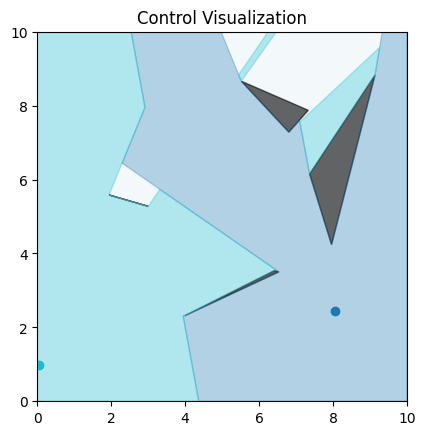

In [ ]:
region_x = 10
region_y = 10
obstacle_count = 4
obstacle_vertex_min = 3
obstacle_vertex_max = 3
faction_count = 2
agent_count = 2

interactiveTestInput = build_random_input(region_x, region_y, obstacle_count, obstacle_vertex_min, obstacle_vertex_max, faction_count, agent_count) # change parameters here!
proposed_algorithm(interactiveTestInput.region, interactiveTestInput.obstacles, interactiveTestInput.agentlist, interactiveTestInput.factions)
plot_faction_control_state(interactiveTestInput.factions, interactiveTestInput.obstacles, interactiveTestInput.region)